In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Normal
import gymnasium as gym
import mani_skill.envs
from tqdm import tqdm
import pandas as pd

# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    raise RuntimeError('No GPU found')

/home/users/ckw24/CS372_Robot_Arm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PPO Class

In [61]:
class PPO():
    def __init__(self, device, env, actor_lr=1e-3, critic_lr=5e-3, clip=.2, gamma=.95):
        self.obs_dim = env.observation_space.shape[1]
        self.act_dim = env.action_space.shape[1]
        self.env = env
        self.actor = nn.Sequential(nn.Linear(self.obs_dim, 512), 
                                   nn.ReLU(),
                                   nn.Linear(512, 512),
                                   nn.ReLU(),
                                   nn.Linear(512, 512),
                                   nn.ReLU(),
                                   nn.Linear(512, self.act_dim),
                                   nn.Tanh()).to(device)
        self.critic = nn.Sequential(nn.Linear(self.obs_dim, 512), 
                                    nn.ReLU(),
                                    nn.Linear(512, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 1)).to(device)
        self.actor_optim = Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optim = Adam(self.critic.parameters(), lr=critic_lr)
        self.clip = clip
        self.gamma = gamma
        self.std = torch.full(size=(self.act_dim,), fill_value=0.1, device=device)
    
    def get_action(self, obs):
        """
			Queries an action from the actor network.

			Parameters:
				obs - the observation at the current timestep as a tensor.
                      tensor of shape (batch_size, observation_dimension)

			Return:
				action - the action to take.
                         tensor of shape (batch_size, action_dimension)
				log_prob - the log probability of the selected action in the distribution
                           tensor of shape (batch_size,)
		"""
        mean = self.actor(obs)
        dist = Normal(mean, self.std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.detach(), log_prob.detach()

    def evaluate(self, obs, action):
        """
			Estimate the values of each observation, and the log probs of
			each action in the most recent batch with the most recent
			iteration of the actor network. Should be called from learn.

			Parameters:
				obs - the observations from the most recently collected batch.
				      tensor of shape (batch_size, time_steps ,observation_dimension)
				action - the actions from the most recently collected batch.
					     tensor of shape (batch_size, time_steps, action_dimension)

			Return:
				v - the predicted values of batch observations
                    tensor of shape (batch_size,)
				log_prob - the log probabilities of the action taken given obs
                           tensor of shape (batch_size,)
		"""
        v = self.critic(obs).squeeze()

        mean = self.actor(obs)
        dist = Normal(mean, self.std)
        log_prob = dist.log_prob(action).sum(dim=-1)
        
        return v, log_prob

## Training Loop

In [62]:
# Parameters
num_batches = 50
batch_size = 64
update_steps = 5
save_freq = 10
patience = 1e9
min_num_batches = 0

# Instantiate env and model
env = gym.make(
    "PickCube-v1",
    num_envs=batch_size,
    obs_mode="state", 
    control_mode="pd_joint_delta_pos", 
    render_mode=None,
    robot_uids="so100"
)

model = PPO(device, env, actor_lr=1e-4, critic_lr=5e-3, clip=.1)
# model.actor.load_state_dict(torch.load('ppo_actor.pth'))
# model.critic.load_state_dict(torch.load('ppo_critic.pth'))

# Training loop
actor_losses = []
critic_losses = []
patience_count = 0
best_actor_loss = 1e9
for batch in tqdm(range(num_batches)):
    batch_obs = []
    batch_actions = []
    batch_log_probs = []
    batch_rewards = []
    batch_mask = []

    # Collect batch data
    obs, _ = env.reset()
    episode_over = False
    while not episode_over:
        batch_obs.append(obs)
        action, log_prob = model.get_action(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        reward -= 0.0    # Small time penalty
        mask = ~(terminated | truncated)
        episode_over = not any(mask)
        batch_actions.append(action)
        batch_log_probs.append(log_prob)
        batch_rewards.append(reward)
        batch_mask.append(mask)
    batch_obs = torch.stack(batch_obs, dim=1).to(device)
    batch_actions = torch.stack(batch_actions, dim=1).to(device)
    batch_log_probs = torch.stack(batch_log_probs, dim=1).to(device)
    batch_rewards = torch.stack(batch_rewards, dim=1).squeeze().to(device)
    batch_mask = torch.stack(batch_mask, dim=1).to(device)

    # Calculate returns 
    batch_timesteps = batch_rewards.shape[1]
    batch_returns = torch.zeros_like(batch_rewards)
    for i in reversed(range(batch_timesteps)):
        if i == batch_timesteps-1: 
            batch_returns[:, i] = batch_rewards[:, i]
        else: 
            batch_returns[:, i] = batch_rewards[:, i] + model.gamma*batch_returns[:, i+1]

    # Determine advantage
    v, _ = model.evaluate(batch_obs, batch_actions)
    A = batch_returns - v.detach()
    A = (A-A.mean())/(A.std()+1e-10)    # Normalization helps with convergence and stability

    # Gradient ascent loop
    actor_loss = 0
    critic_loss = 0
    for _ in range(update_steps):
        # Calculate prob with new model params and determine prob ratio
        v, current_log_probs = model.evaluate(batch_obs, batch_actions)
        ratios = torch.exp(current_log_probs-batch_log_probs)
        
        # Surrogate loss function
        surr1 = ratios*A
        surr2 = torch.clamp(ratios, 1-model.clip, 1+model.clip)*A
        actor_loss = (-1*torch.min(surr1, surr2)*batch_mask).sum()/(batch_mask.sum())

        # Critic loss function
        mse = nn.MSELoss(reduction='none')
        critic_loss = (mse(v, batch_returns)*batch_mask).sum()/(batch_mask.sum())
        
        # Perform gradient steps 
        model.actor_optim.zero_grad()
        actor_loss.backward()
        model.actor_optim.step()

        model.critic_optim.zero_grad()
        critic_loss.backward()
        model.critic_optim.step()

        # Record loss values
        actor_losses.append(actor_loss.item())
        critic_losses.append(critic_loss.item())
    
    # Check for early stopping
    stop_cond = False
    if actor_losses[-1] > best_actor_loss:
        patience_count += 1
    else: 
        patience_count = 0
        best_actor_loss = actor_losses[-1]

    if batch+1 > min_num_batches and patience_count >= patience:
        stop_cond = True

    # Save model params and log data
    if (batch+1)%save_freq == 0 or stop_cond or batch+1 == num_batches: 
        torch.save(model.actor.state_dict(), 'ppo_actor.pth')
        torch.save(model.critic.state_dict(), 'ppo_critic.pth')
        df = pd.DataFrame({'Actor Losses': actor_losses, 'Critic losses':critic_losses})
        df.to_csv('Training Data.csv')
    
    if stop_cond: 
        print(f'Stopping early after {batch+1:d} batches')
        break

100%|██████████| 50/50 [00:37<00:00,  1.34it/s]


In [63]:
print(A)
print(ratios)

tensor([[-0.9180, -0.9400, -0.8784,  ..., -1.4792, -1.7333, -1.7996],
        [ 0.3774,  0.3551,  0.4182,  ..., -0.9975, -1.1793, -1.4672],
        [ 1.0704,  1.0294,  0.9796,  ..., -1.6405, -1.9139, -2.0788],
        ...,
        [-0.3018, -0.3222, -0.2916,  ..., -1.2042, -1.3300, -1.4229],
        [ 0.4821,  0.4367,  0.2369,  ..., -1.9492, -2.1142, -2.3246],
        [ 1.3560,  1.3166,  1.4455,  ..., -1.0704, -1.2207, -1.4645]],
       device='cuda:0')
tensor([[0.9608, 1.0645, 0.9809,  ..., 0.9815, 0.9725, 1.0006],
        [0.9467, 0.9738, 1.0830,  ..., 1.0264, 0.9951, 0.9354],
        [1.0689, 1.0649, 1.1159,  ..., 0.9758, 0.9864, 0.8966],
        ...,
        [1.0521, 0.9673, 0.9333,  ..., 0.9712, 1.0032, 1.0119],
        [1.1144, 1.0134, 1.0133,  ..., 1.0406, 0.9915, 1.0056],
        [1.0081, 1.0127, 1.0331,  ..., 1.0355, 0.9868, 0.9174]],
       device='cuda:0', grad_fn=<ExpBackward0>)


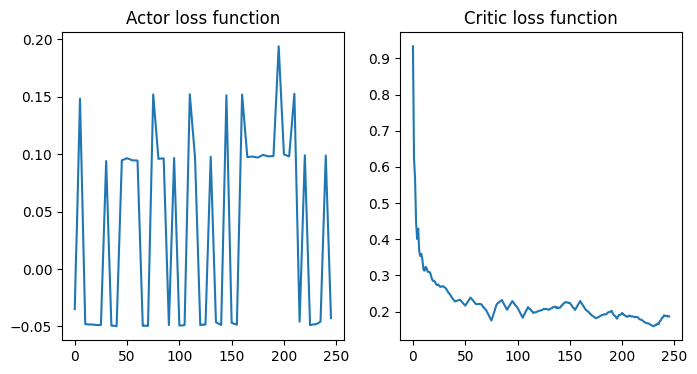

In [64]:
df = pd.read_csv('Training Data.csv')
actor_losses = df['Actor Losses'].to_numpy()
critic_losses = df['Critic losses'].to_numpy()

smoothing = 5
fig, plts = plt.subplots(1, 2, num=1, clear=True, figsize = (8, 4))
plts[0].plot(np.convolve(actor_losses, np.ones(smoothing), 'valid') / smoothing)
plts[1].plot(np.convolve(critic_losses, np.ones(smoothing), 'valid') / smoothing)
plts[0].set(title='Actor loss function')
plts[1].set(title='Critic loss function')
fig.show()

## Evaluation

In [65]:

env = gym.make(
    "PickCube-v1", # there are more tasks e.g. "PushCube-v1", "PegInsertionSide-v1", ...
    num_envs=8,
    obs_mode="state", # there is also "state_dict", "rgbd", ...
    control_mode="pd_joint_delta_pos", 
    render_mode="rgb_array",
    robot_uids="so100"
)
model = PPO(device, env)
model.actor.load_state_dict(torch.load('ppo_actor.pth'))
model.critic.load_state_dict(torch.load('ppo_critic.pth'))

obs, _ = env.reset()
episode_over = False
frames = [env.render().cpu().numpy()]
while not episode_over:
    with torch.no_grad():
        action, _ = model.get_action(obs)
    obs, _, terminated, truncated, _ = env.step(action)
    frames.append(env.render().cpu().numpy())
    episode_over = all(terminated | truncated)
frames = np.stack(frames, axis=1)

In [66]:


fig = plt.figure(num=2, clear=True, figsize=(9, 5))
axes = []
for i in range(frames.shape[0]):
    axes.append(fig.add_subplot(2, int(frames.shape[0]/2), i+1))
    axes[i].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
    axes[i].imshow(frames[i][0])
fig.tight_layout()

ims = []
for i in range(frames.shape[1]):    # Loop over each timestep 
    images = []
    for j in range(frames.shape[0]):    # Loop over each arm in the batch
        image = axes[j].imshow(frames[j][i], animated=True)
        images.append(image)
    ims.append(images)

ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
plt.close(fig=2)
display(HTML(ani.to_html5_video()))